In [ ]:
pip install pandas numpy scikit-learn tensorflow mealpy

Eğitim verisi boyutu: (118, 3, 2)
Test verisi boyutu: (30, 3, 2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model eğitiliyor, lütfen bekleyin...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.5832 - val_loss: 0.3687
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3456 - val_loss: 0.1857
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1646 - val_loss: 0.0578
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0474 - val_loss: 0.0030
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0134 - val_loss: 0.0112
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0217 - val_loss: 0.0106
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0157 - val_loss: 0.0024
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0125 - val_loss: 0.0016
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0131 - val_loss: 0.0015
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0125 - val_loss: 0.0016
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0121 - val_loss: 0.0021
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/ste

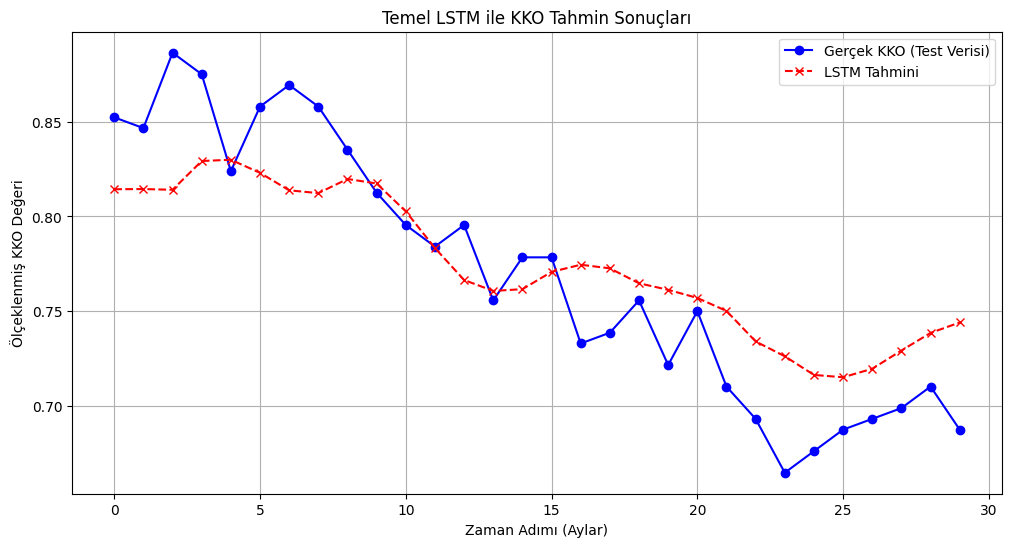

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. VERİYİ YÜKLEME
df = pd.read_csv("veri.csv")

# Hedefimiz KKO_MA'yı tahmin etmek. Girdi olarak hem KKO_MA hem de RKGA_MA kullanacağız.
data = df[['KKO_MA', 'RKGA_MA']].values

# 2. VERİYİ ÖLÇEKLENDİRME (0 ile 1 arasına sıkıştırma)
# Yapay sinir ağları büyük sayılarla çalışmayı sevmez, bu yüzden veriyi [0, 1] aralığına çekiyoruz.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. ZAMAN SERİSİ PENCERELERİ (LOOK-BACK) OLUŞTURMA
# Modelin geçmiş kaç aya bakarak geleceği tahmin edeceğini belirliyoruz. (Örn: 3 ay)
look_back = 3

X, Y = [], []
for i in range(len(scaled_data) - look_back):
    # X: Girdi (Son 3 ayın KKO ve RKGA verileri)
    X.append(scaled_data[i:(i + look_back), :])
    # Y: Çıktı (Tahmin edilecek KKO değeri, yani sütun indeksi 0)
    Y.append(scaled_data[i + look_back, 0])

X = np.array(X)
Y = np.array(Y)

# 4. VERİYİ BÖLME (%80 Eğitim, %20 Test)
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

print(f"Eğitim verisi boyutu: {X_train.shape}")
print(f"Test verisi boyutu: {X_test.shape}")

# 5.LSTM MODELİ KURMA
model = Sequential()
# 50 nöronlu, düz bir LSTM katmanı
model.add(LSTM(units=50, activation='tanh', input_shape=(look_back, 2)))
# Tek bir değer (KKO) tahmin edeceğimiz için 1 nöronlu çıktı katmanı
model.add(Dense(units=1))

# Modeli derleme (Hata fonksiyonu olarak MSE kullanıyoruz)
model.compile(optimizer='adam', loss='mean_squared_error')

# 6. MODELİ EĞİTME
print("Model eğitiliyor, lütfen bekleyin...")
history = model.fit(
    X_train, Y_train,
    epochs=50,          # Veri setinin üzerinden kaç kez geçilecek
    batch_size=16,      # Her adımda kaç veri işlenecek
    validation_data=(X_test, Y_test), # Test verisiyle başarıyı ölç
    verbose=1           # Eğitim sürecini ekrana yazdır
)

# 7. TAHMİN YAPMA VE GÖRSELLEŞTİRME
# Test verisi üzerinden modelin tahminlerini alıyoruz
predictions = model.predict(X_test)

# Grafik çizdirme (Gerçek KKO vs Tahmin Edilen KKO - Ölçeklenmiş halleriyle)
plt.figure(figsize=(12, 6))
plt.plot(Y_test, color='blue', label='Gerçek KKO (Test Verisi)', marker='o')
plt.plot(predictions, color='red', label='LSTM Tahmini', linestyle='dashed', marker='x')
plt.title('Temel LSTM ile KKO Tahmin Sonuçları')
plt.xlabel('Zaman Adımı (Aylar)')
plt.ylabel('Ölçeklenmiş KKO Değeri')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Temel LSTM için Hata Metriklerinin Hesaplanması
mse_lstm = mean_squared_error(Y_test, predictions)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(Y_test, predictions)

print(mse_lstm)
print(rmse_lstm)
print(mae_lstm)

0.0012457246762578244
0.03529482506342572
0.030003741473862564
